In [4]:
from google.colab import files
uploaded = files.upload()


Saving WA_Fn-UseC_-Telco-Customer-Churn.csv to WA_Fn-UseC_-Telco-Customer-Churn (2).csv


In [5]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Total Customers: 7032
Churned Customers: 1869
Churn Rate: 26.58 %


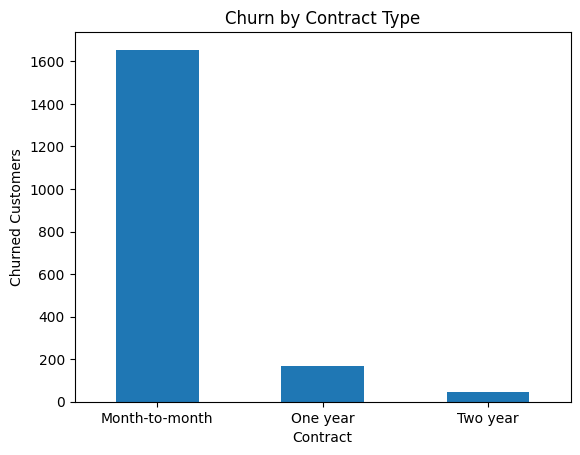

In [6]:
import matplotlib.pyplot as plt

# Clean TotalCharges
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df = df.dropna()

# Create Churn Flag
df["Churn_Flag"] = df["Churn"].apply(lambda x: 1 if x == "Yes" else 0)

# KPI
total = df.shape[0]
churned = df["Churn_Flag"].sum()
churn_rate = churned / total

print("Total Customers:", total)
print("Churned Customers:", churned)
print("Churn Rate:", round(churn_rate * 100, 2), "%")

# Analysis
contract_churn = df.groupby("Contract")["Churn_Flag"].sum()

# Chart
contract_churn.plot(kind="bar")
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Churned Customers")
plt.xticks(rotation=0)
plt.show()